In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [2]:
## df = pd.read_csv("db_bereinigt.csv")  # alte csv

#df = pd.read_csv("db_bereinigt_fertig.csv") # aktuelle Datenbank Stand 06.07.2026

df = pd.read_csv("db_bereinigt_final.csv") # aktuelle Datenbank Stand 13.07.2026

In [3]:
'''
# Daten aus Datenbank einlesen

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
db_password = os.getenv("DB_PASSWORD")

# Verbindungsdaten anpassen
db_user = 'neondb_owner'
db_host = 'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech'
db_port = '5432'
db_name = 'neondb'

# Engine erstellen
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

# SQL-Query definieren und Daten in den DataFrame laden
query = "SELECT * FROM ashrae_consolidado"
df = pd.read_sql(query, con=engine)

# Erste Zeilen zur Kontrolle anzeigen
display(df.head())
'''

'\n# Daten aus Datenbank einlesen\n\nfrom sqlalchemy import create_engine\nimport os\nfrom dotenv import load_dotenv\n\nload_dotenv()\ndb_password = os.getenv("DB_PASSWORD")\n\n# Verbindungsdaten anpassen\ndb_user = \'neondb_owner\'\ndb_host = \'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech\'\ndb_port = \'5432\'\ndb_name = \'neondb\'\n\n# Engine erstellen\nengine = create_engine(f\'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}\')\n\n# SQL-Query definieren und Daten in den DataFrame laden\nquery = "SELECT * FROM ashrae_consolidado"\ndf = pd.read_sql(query, con=engine)\n\n# Erste Zeilen zur Kontrolle anzeigen\ndisplay(df.head())\n'

In [4]:

df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'building_type', 'air_speed', 'metabolic_rate', 'climate_zone', 'cooling_type', 'clothing_ensemble_insulation']]
df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)
df_ml_clo_clean = df_ml_clo.dropna()
df_X = df_ml_clo_clean

C:\Users\User\AppData\Local\Temp\ipykernel_3796\689429316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)


In [5]:
'''
# Externer Datensatz fertig vorsortiert und nur die erforderlichen Spalten
# exportierte Daten aus dem Modell zur Vorhersage der clo
X_train = pd.read_csv('X_train.csv', sep=';')
y_train = pd.read_csv('y_train.csv', sep=';')
df_X = X_train.copy()
df_X['clothing_ensemble_insulation'] = y_train
df_X = df_X.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)
'''

"\n# Externer Datensatz fertig vorsortiert und nur die erforderlichen Spalten\n# exportierte Daten aus dem Modell zur Vorhersage der clo\nX_train = pd.read_csv('X_train.csv', sep=';')\ny_train = pd.read_csv('y_train.csv', sep=';')\ndf_X = X_train.copy()\ndf_X['clothing_ensemble_insulation'] = y_train\ndf_X = df_X.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)\n"

Da der Datensatz nicht auf bestimmt Klimazonen oder Gebäudetypen gefiltert ist, sind extrem viele Anomalien zu erwarten. Der Datensatz sollte sehr viel mehr eingescränkt werden!!!
Oder auch Trennung nach Cooling Strategy

In [6]:
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Eine Pipeline wie bei Regression oder Klassifikation ist nicht notwendig!
# Pipeline nur notwendig, wenn man zum Beispiel Cluster erstellen möchte für eine spätere Klassifikation

# 2. Features extrahieren und skalieren
# Da Temperaturen und Feuchtigkeiten unterschiedliche Skalen haben (z.B. 20°C vs 1013 hPa),
# ist die Standardisierung hier absolut zwingend erforderlich!
#features = df_X.columns

# Es werden nur numerische Features verwendet
# kategrorische Features sollten nicht in DBSCAN verwendet werden, dafür ist ein Isolation Forest sinnvoller
# DBSCAN sucht nach Dichtewolken, hier wären Features die keine sinnvollen kontinuierlichen Werte haben störend!

features = [
    'outdoor_air_temperature', 
    'air_temperature', 
    'relative_humidity', 
    'air_speed', 
    'metabolic_rate', 
    'clothing_ensemble_insulation'
]

scaler = StandardScaler()   #   vereinfacht alles mit StandardScaler, alternativ wäre ein PowerTransformer oder anderer Scaler mgl. am besten aber alles gleich skalieren
X_scaled = scaler.fit_transform(df_X[features])
'''

"\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.cluster import DBSCAN\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\n\n# Eine Pipeline wie bei Regression oder Klassifikation ist nicht notwendig!\n# Pipeline nur notwendig, wenn man zum Beispiel Cluster erstellen möchte für eine spätere Klassifikation\n\n# 2. Features extrahieren und skalieren\n# Da Temperaturen und Feuchtigkeiten unterschiedliche Skalen haben (z.B. 20°C vs 1013 hPa),\n# ist die Standardisierung hier absolut zwingend erforderlich!\n#features = df_X.columns\n\n# Es werden nur numerische Features verwendet\n# kategrorische Features sollten nicht in DBSCAN verwendet werden, dafür ist ein Isolation Forest sinnvoller\n# DBSCAN sucht nach Dichtewolken, hier wären Features die keine sinnvollen kontinuierlichen Werte haben störend!\n\nfeatures = [\n    'outdoor_air_temperature', \n    'air_temperature', \n    'relative_humidity', \n    'air_speed', \n    'metabolic_

In [7]:
'''
# Ermittlung des eps-Wertes über NearestNeighbors

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# 1. min_samples festlegen (Daumenregel: Features * 2 = 12)
# Wir nutzen min_samples - 1 für die Nachbarschaftssuche, da der Punkt sich selbst mitzählt
#k = 12 # 6 Feature * 2 = 12
k = 100 # erzeugt k Spalten für die Distanzmatrix
# eigentlich ein fixer Wert, wenn sich dadurch schon ein Knick einstellt
# bei sehr großen Datensätzen mit mehreren tausen Zeilen ggf. erhöhen zu k=25,50 oder sogar 100
# bei wenigen Hunder verringern

# Es werden jetzt im Algortihmus die Abstände zu den 12 nächsten Nachbarn in 2 bestimmt.

# 2. Die Abstände zu den k-nächsten Nachbarn berechnen
# X_scaled sind Ihre bereits standardisierten Sensordaten
nearest_neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Die Abstände der k-ten Nachbarn sortieren (nur die letzte Spalte von distances)
sorted_distances = np.sort(distances[:, k-1])   # Hier wird nur der Abstand zum k-ten Nachbar benötigt, der Rest der Matrix wird später verwendet

# 4. Den Graphen zeichnen
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, color='blue', lw=2)

# Achsenbeschriftung und Layout
plt.title('K-Abstand-Graph zur Bestimmung von eps', fontsize=14)
plt.xlabel('Datenpunkte (nach Abstand sortiert)', fontsize=12)
plt.ylabel(f'Abstand zum {k}-nächsten Nachbarn (eps-Wert)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Den aktuellen Wert von 2.5 als Orientierungslinie einzeichnen
#plt.axhline(y=2.5, color='red', linestyle=':', label='Aktuelles eps = 2.5')
plt.axhline(y=1.8, color='red', linestyle=':', label='Aktuelles eps = 1.8') # eps ist der Abstand zwischen den Werten durch den Standardscaler ist er jetzt um den Wert 1 rum!!!
plt.legend()

plt.show()
'''


"\n# Ermittlung des eps-Wertes über NearestNeighbors\n\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.neighbors import NearestNeighbors\n\n# 1. min_samples festlegen (Daumenregel: Features * 2 = 12)\n# Wir nutzen min_samples - 1 für die Nachbarschaftssuche, da der Punkt sich selbst mitzählt\n#k = 12 # 6 Feature * 2 = 12\nk = 100 # erzeugt k Spalten für die Distanzmatrix\n# eigentlich ein fixer Wert, wenn sich dadurch schon ein Knick einstellt\n# bei sehr großen Datensätzen mit mehreren tausen Zeilen ggf. erhöhen zu k=25,50 oder sogar 100\n# bei wenigen Hunder verringern\n\n# Es werden jetzt im Algortihmus die Abstände zu den 12 nächsten Nachbarn in 2 bestimmt.\n\n# 2. Die Abstände zu den k-nächsten Nachbarn berechnen\n# X_scaled sind Ihre bereits standardisierten Sensordaten\nnearest_neighbors = NearestNeighbors(n_neighbors=k)\nneighbors_fit = nearest_neighbors.fit(X_scaled)\ndistances, indices = neighbors_fit.kneighbors(X_scaled)\n\n# 3. Die Abstände der k-ten Nach

Der Knick beschreibt den Bereich wo sich der Abstand zwischen Datenpunkten recht schnell ändert und somit die Grenze zwischen zwei Clustern zu erwarten ist.

In [8]:
'''
# 3. DBSCAN anwenden
# Bei 6 Dimensionen muss 'eps' oft etwas größer gewählt werden als bei 2 Dimensionen.
# 'min_samples' wird oft auf mindestens: Anzahl der Features * 2 (hier ca. 12) gesetzt.
# Anzupassende Parameter!!!!!!!!!!!!!!!!!!!! eps ist der Suchradius, je kleiner, deste mehr Anomalien die gefunden werden, min_samples Mindestwerte pro Cluster, je höher desto strenger und deste mehr anomalien

#eps = 2.5
#min_samples = 12

#dbscan = DBSCAN(eps = eps, min_samples= min_samples)
#dbscan = DBSCAN(eps=2.5, min_samples=12)    # hiermit 13 sehr eindeutige Anomalien
#dbscan = DBSCAN(eps=2.0, min_samples=12)    # hiermit 61 Anomalien, die im PCA1/PCA2 Raum nicht eindeutig sind! Und es werden 3 Cluster erkannt!!!
#dbscan = DBSCAN(eps=3.0, min_samples=12)    # hiermit 61 Anomalien, die im PCA1/PCA2 Raum nicht eindeutig sind! Und es werden 3 Cluster erkannt!!!

#dbscan = DBSCAN(eps=1.0, min_samples=12)    # aus K-Abstandsdiagramm # für k = 12
dbscan = DBSCAN(eps=1.8, min_samples=100)    # aus K-Abstandsdiagramm # für k = 100

df_X['Cluster'] = dbscan.fit_predict(X_scaled)

##################################################################
############## Ende des eigentlichen Algorithmus #################
##################################################################

# Anomalie-Flag setzen (-1 bedeutet Anomalie bei DBSCAN)
df_X['Is_Anomaly'] = df_X['Cluster'] == -1

# Statistik ausgeben
num_anomalies = df_X['Is_Anomaly'].sum()
print(f"Datensatz geladen mit {df_X.shape[0]} Zeilen.")
print(f"Erkannte Anomalien: {num_anomalies} (({num_anomalies/len(df_X)*100:.2f}%)")

# 4. Visualisierung Option A: Dimensionsreduktion via PCA (für den schnellen Überblick)
# PCA Analyse - Hauptkomponentenanalyse als visuelles Hilfsmittel
pca = PCA(n_components=2, random_state=42)  #   Algorithmus initialisieren und auf 2 Hauptkomponenten festlegen
#pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_X['PCA1'] = X_pca[:, 0]
df_X['PCA2'] = X_pca[:, 1]

#plt.figure(figsize=(10, 6))
## Normale Daten im Hintergrund
#sns.scatterplot(data=df_X[~df_X['Is_Anomaly']], x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.7)
## Anomalien markant in Rot hervorheben
#sns.scatterplot(data=df_X[df_X['Is_Anomaly']], x='PCA1', y='PCA2', color='red', marker='X', s=150, label='Anomalie')
#plt.title('DBSCAN Anomalieerkennung (6D auf 2D projiziert via PCA - Hauptkomponentenanalyse)')
#plt.legend()
#plt.show()

print(f"Anomalien meisten zwischen 0.5 und 1.8%")
'''

'\n# 3. DBSCAN anwenden\n# Bei 6 Dimensionen muss \'eps\' oft etwas größer gewählt werden als bei 2 Dimensionen.\n# \'min_samples\' wird oft auf mindestens: Anzahl der Features * 2 (hier ca. 12) gesetzt.\n# Anzupassende Parameter!!!!!!!!!!!!!!!!!!!! eps ist der Suchradius, je kleiner, deste mehr Anomalien die gefunden werden, min_samples Mindestwerte pro Cluster, je höher desto strenger und deste mehr anomalien\n\n#eps = 2.5\n#min_samples = 12\n\n#dbscan = DBSCAN(eps = eps, min_samples= min_samples)\n#dbscan = DBSCAN(eps=2.5, min_samples=12)    # hiermit 13 sehr eindeutige Anomalien\n#dbscan = DBSCAN(eps=2.0, min_samples=12)    # hiermit 61 Anomalien, die im PCA1/PCA2 Raum nicht eindeutig sind! Und es werden 3 Cluster erkannt!!!\n#dbscan = DBSCAN(eps=3.0, min_samples=12)    # hiermit 61 Anomalien, die im PCA1/PCA2 Raum nicht eindeutig sind! Und es werden 3 Cluster erkannt!!!\n\n#dbscan = DBSCAN(eps=1.0, min_samples=12)    # aus K-Abstandsdiagramm # für k = 12\ndbscan = DBSCAN(eps=1.8, 

Besseren Ansatz mit PowerTransformer und StandardScaler

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.cluster import DBSCAN

# 1. Feature-Gruppen definieren
schiefe_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']
normale_features = ['air_temperature', 'outdoor_air_temperature', 'relative_humidity']

# 2. Preprocessor bauen
preprocessor = ColumnTransformer(
    transformers=[
        # PowerTransformer normalisiert UND skaliert die schiefen Spalten automatisch
        ('schief', PowerTransformer(method='yeo-johnson'), schiefe_features),
        # Normale Features brauchen nur den StandardScaler
        ('normal', StandardScaler(), normale_features)
    ]
)


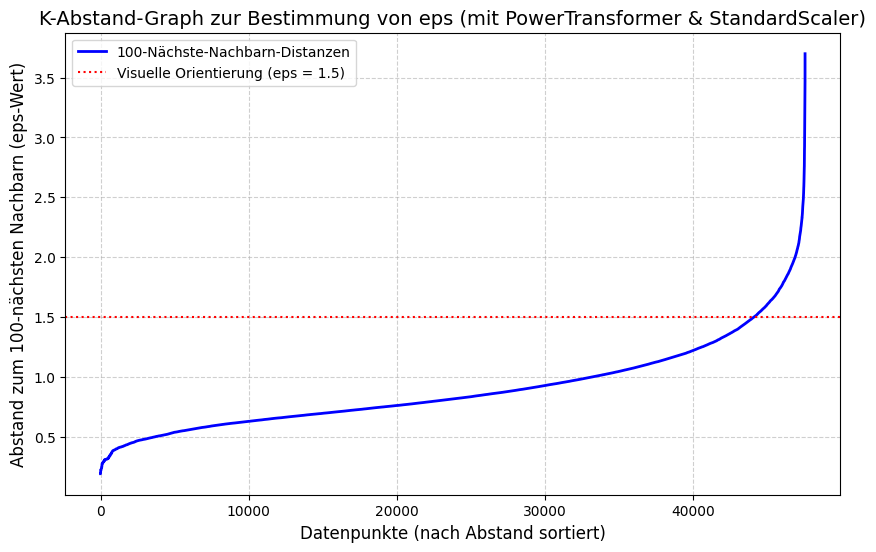

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. Daten über den Preprocessor transformieren
# ==========================================
# Wir nutzen den ColumnTransformer aus deiner Pipeline, 
# um die schiefen und normalen Features exakt so vorzubereiten wie für DBSCAN.
X_transformed = preprocessor.fit_transform(df_X)

# ==========================================
# 2. Parameter festlegen (k-Nachbarn)
# ==========================================
# Bei großen Datensätzen ist k=100 eine gute Wahl, um stabilere Knicke zu sehen.
k = 100 

# ==========================================
# 3. Abstände berechnen
# ==========================================
# Wir füttern die NearestNeighbors mit den frisch transformierten Daten
nearest_neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = nearest_neighbors.fit(X_transformed)
distances, indices = neighbors_fit.kneighbors(X_transformed)

# 4. Abstände zum k-ten Nachbarn sortieren (Index k-1 ist die letzte Spalte)
sorted_distances = np.sort(distances[:, k-1])

# ==========================================
# 5. K-Abstand-Graph zeichnen
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, color='blue', lw=2, label=f'{k}-Nächste-Nachbarn-Distanzen')

# Achsenbeschriftung und Layout
plt.title('K-Abstand-Graph zur Bestimmung von eps (mit PowerTransformer & StandardScaler)', fontsize=14)
plt.xlabel('Datenpunkte (nach Abstand sortiert)', fontsize=12)
plt.ylabel(f'Abstand zum {k}-nächsten Nachbarn (eps-Wert)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Flexibler Bereich für deine Orientierungslinie
# Da der PowerTransformer die Daten staucht, wird sich der "Knick" vermutlich
# in einem Bereich zwischen 0.5 und 2.0 einpendeln.
optimales_eps_schaetzung = 1.5  # Passe diesen Wert nach dem ersten Plotten an!
plt.axhline(y=optimales_eps_schaetzung, color='red', linestyle=':', 
            label=f'Visuelle Orientierung (eps = {optimales_eps_schaetzung})')

plt.legend()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_3796\2887179346.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['Cluster'] = dbscan_pipeline.fit_predict(df_X)
C:\Users\User\AppData\Local\Temp\ipykernel_3796\2887179346.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['Is_Anomaly'] = df_X['Cluster'] == -1
C:\Users\User\AppData\Local\Temp\ipykernel_3796\2887179346.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

Datensatz geladen mit 47584 Zeilen.
Erkannte Anomalien: 74 (0.16%)
Anomalien meistens zwischen 0.5 und 1.8%


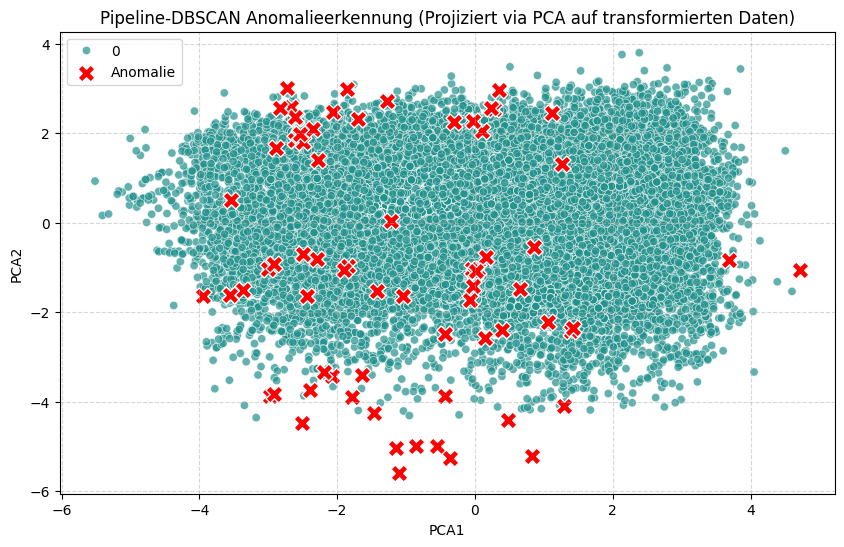

In [11]:
from sklearn.decomposition import PCA

dbscan_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dbscan', DBSCAN(eps=1.8, min_samples=100))
])

# ==================================================================
# 3. Pipeline anwenden und Ergebnisse speichern
# ==================================================================
# Wir übergeben dem Clustering nur die relevanten Feature-Spalten
#df_X['Cluster'] = dbscan_pipeline.fit_predict(df_X[features])
df_X['Cluster'] = dbscan_pipeline.fit_predict(df_X)

# Anomalie-Flag setzen (-1 bedeutet Anomalie bei DBSCAN)
df_X['Is_Anomaly'] = df_X['Cluster'] == -1

# ==================================================================
# Statistik ausgeben
# ==================================================================
num_anomalies = df_X['Is_Anomaly'].sum()
print(f"Datensatz geladen mit {df_X.shape[0]} Zeilen.")
print(f"Erkannte Anomalien: {num_anomalies} ({num_anomalies/len(df_X)*100:.2f}%)")
print("Anomalien meistens zwischen 0.5 und 1.8%")

# ==================================================================
# 4. Visualisierung via PCA (auf den transformierten Daten)
# ==================================================================
# Wir holen uns die fertig transformierten Daten aus der Pipeline
#X_transformed = dbscan_pipeline.named_steps['preprocessor'].transform(df_X[features])
X_transformed = dbscan_pipeline.named_steps['preprocessor'].transform(df_X)

# PCA initialisieren und auf 2 Hauptkomponenten festlegen
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

df_X['PCA1'] = X_pca[:, 0]
df_X['PCA2'] = X_pca[:, 1]

# Plot erstellen
plt.figure(figsize=(10, 6))

# Normale Daten im Hintergrund zeichnen
sns.scatterplot(
    data=df_X[~df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    hue='Cluster', palette='viridis', alpha=0.7
)

# Anomalien markant in Rot hervorheben
sns.scatterplot(
    data=df_X[df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    color='red', marker='X', s=150, label='Anomalie'
)

plt.title('Pipeline-DBSCAN Anomalieerkennung (Projiziert via PCA auf transformierten Daten)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3796\1487346145.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['PCA1'] = X_pca[:, 0]
C:\Users\User\AppData\Local\Temp\ipykernel_3796\1487346145.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['PCA2'] = X_pca[:, 1]


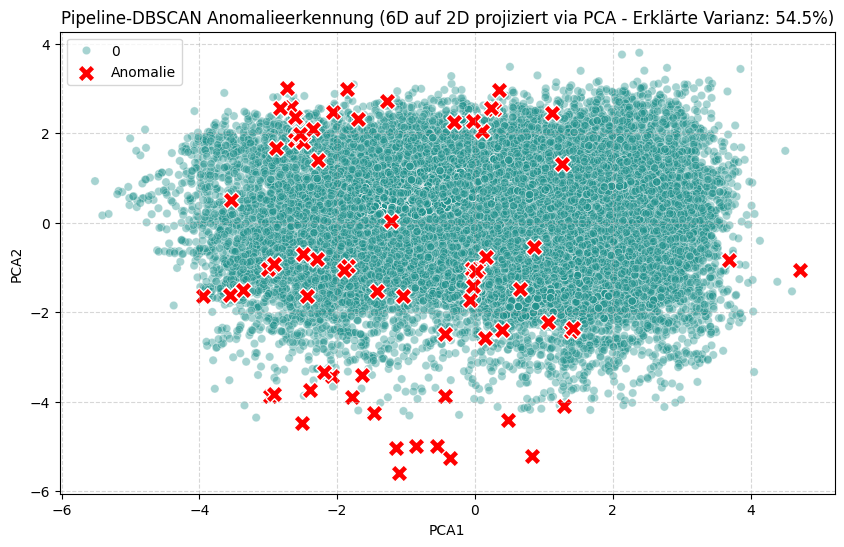

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ==================================================================
# 4. Visualisierung via PCA (auf den transformierten Daten der Pipeline)
# ==================================================================

# 1. Die fertig transformierten Daten aus dem Preprocessor der Pipeline holen
# Wir übergeben genau die Features, die auch DBSCAN gesehen hat
X_transformed = dbscan_pipeline.named_steps['preprocessor'].transform(df_X)

# 2. PCA initialisieren und auf den transformierten Daten fitten
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

# 3. Hauptkomponenten im DataFrame speichern
df_X['PCA1'] = X_pca[:, 0]
df_X['PCA2'] = X_pca[:, 1]

# 4. Erklärte Varianz direkt nach dem PCA-Fit berechnen
var_exp = pca.explained_variance_ratio_
total_var = np.sum(var_exp) * 100

# 5. Diagramm zeichnen
plt.figure(figsize=(10, 6))

# Normale Daten im Hintergrund (mit Alpha für bessere Sichtbarkeit der Dichte)
sns.scatterplot(
    data=df_X[~df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    hue='Cluster', palette='viridis', alpha=0.4
)

# Anomalien markant in Rot hervorheben
sns.scatterplot(
    data=df_X[df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    color='red', marker='X', s=150, label='Anomalie'
)

# Dynamischen Titel mit der erklärten Varianz setzen
plt.title(f'Pipeline-DBSCAN Anomalieerkennung (6D auf 2D projiziert via PCA - Erklärte Varianz: {total_var:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Diagramm final ausgeben
plt.show()


Erklärte Varianz bei 52.8, also wenig aussagekräftig. Wünschenswert wären 70% und mehr!

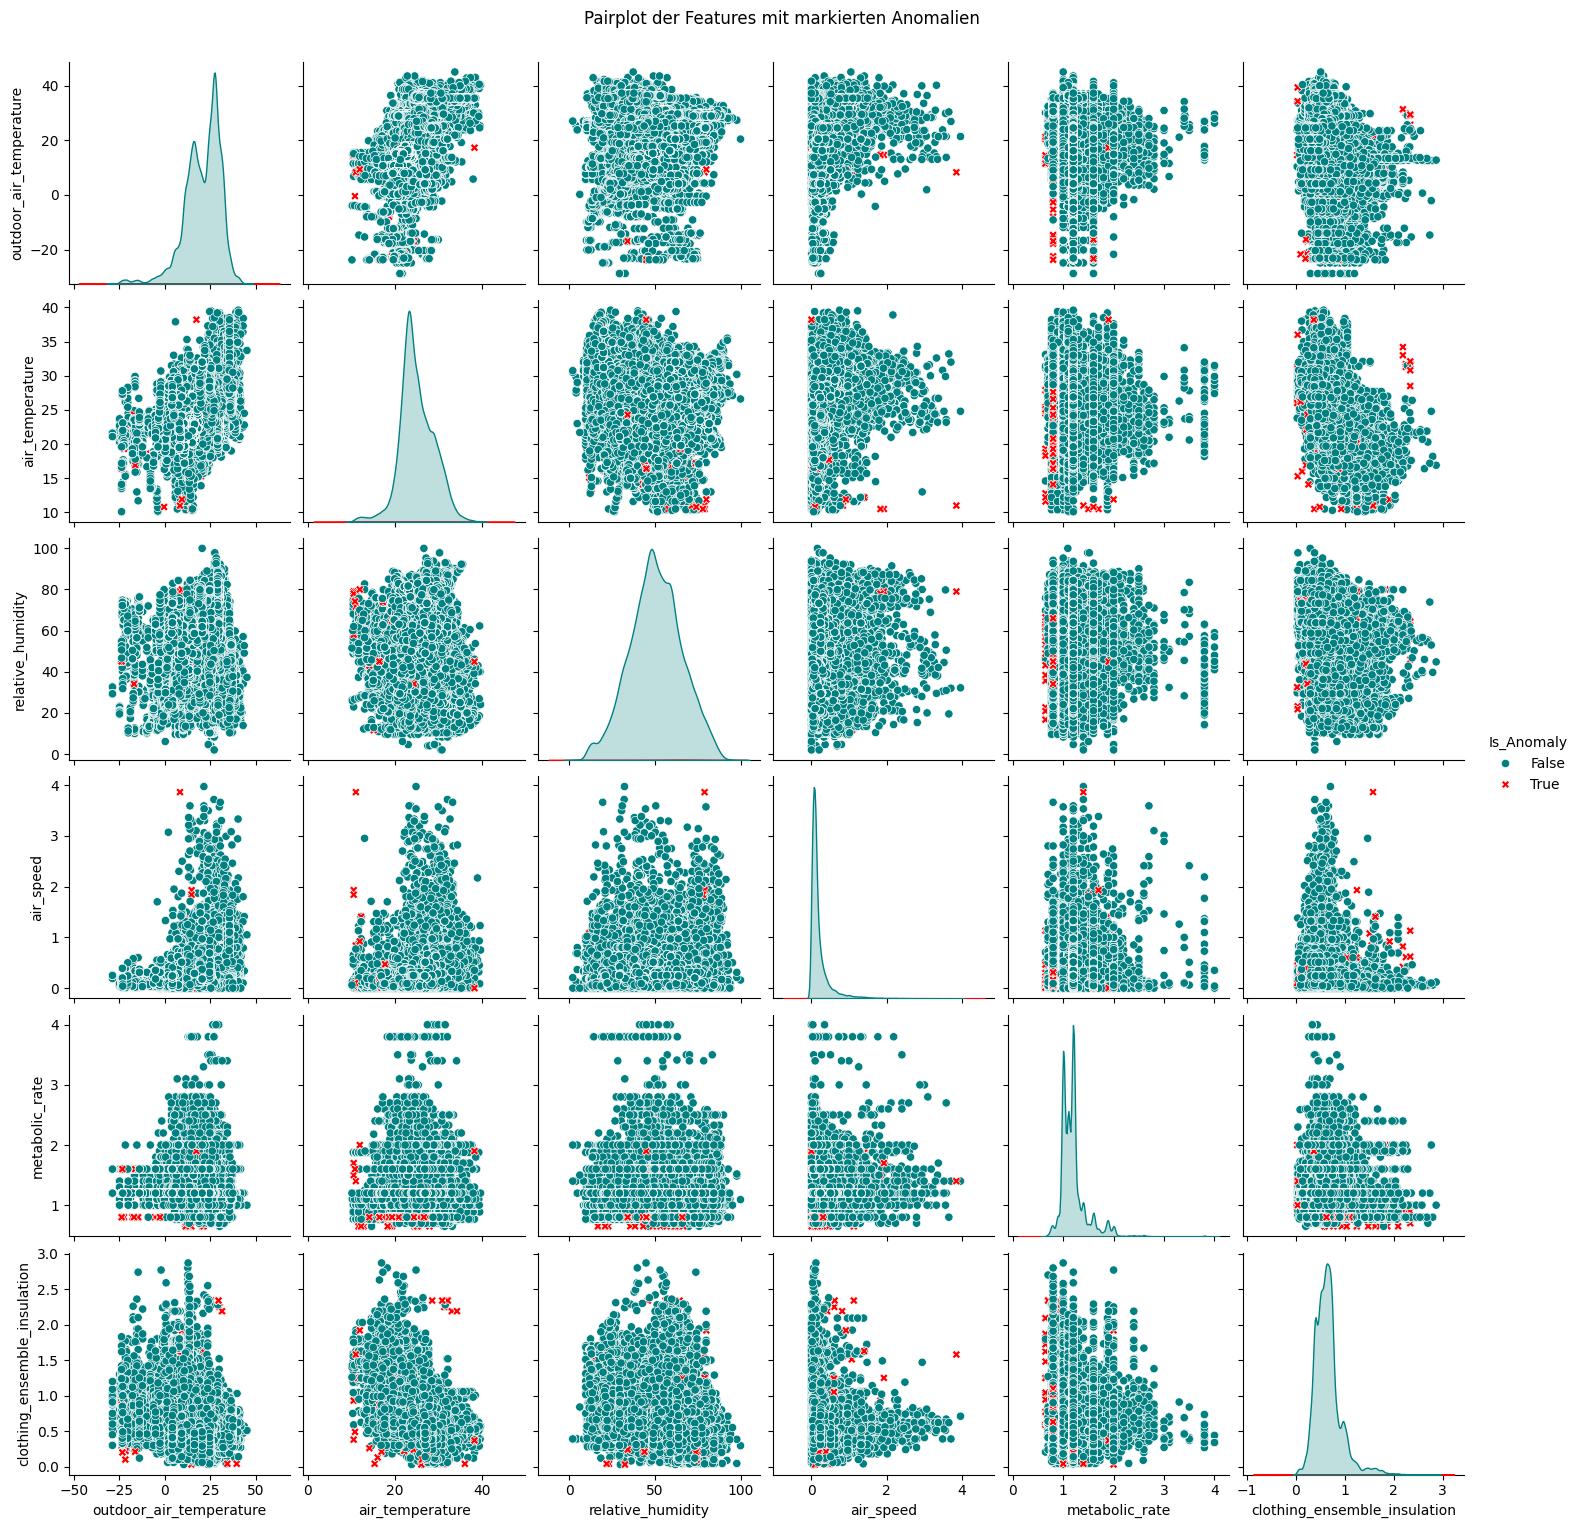

In [13]:
# 5. Visualisierung Option B: Pairplot der wichtigsten Features (Ausschnitt)
# Zeigt, in welchen Feature-Kombinationen die Anomalien aus der Reihe tanzen
#selected_features = ['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'Is_Anomaly']
selected_features = ['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation', 'Is_Anomaly']
sns.pairplot(df_X[selected_features], hue='Is_Anomaly', palette={False: 'teal', True: 'red'}, markers=['o', 'X'])
plt.suptitle('Pairplot der Features mit markierten Anomalien', y=1.02)
plt.show()

In [14]:
df_X

,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,climate_zone,cooling_type,clothing_ensemble_insulation,Cluster,Is_Anomaly,PCA1,PCA2
0,15.86,22.3,61.0,winter,office,0.03,1.706485,Temperate,mixed mode,0.95,0,False,-1.638480,1.538205
1,15.86,23.0,59.0,winter,office,0.08,1.109215,Temperate,mixed mode,1.07,0,False,-1.216043,-0.195602
2,15.86,22.0,61.0,winter,office,0.04,1.211604,Temperate,mixed mode,0.88,0,False,-1.375139,0.453124
3,15.86,23.2,58.0,winter,office,0.03,1.774744,Temperate,mixed mode,0.59,0,False,-1.006025,1.870601
4,15.86,22.2,62.0,winter,office,0.15,1.484642,Temperate,mixed mode,0.83,0,False,-0.855590,1.332454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107848,9.20,26.9,49.0,winter,others,0.51,1.200000,Temperate,naturally ventilated,0.14,0,False,1.653943,1.193128
107849,9.20,26.9,49.0,winter,others,0.51,1.200000,Temperate,naturally ventilated,0.31,0,False,1.046509,0.795804
107850,9.20,26.9,49.0,winter,others,0.51,1.200000,Temperate,naturally ventilated,0.40,0,False,0.792026,0.629346
107851,9.20,26.9,49.1,winter,others,0.51,1.200000,Temperate,naturally ventilated,0.40,0,False,0.793415,0.632423


C:\Users\User\AppData\Local\Temp\ipykernel_3796\1722074922.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['PCA1'] = X_pca[:, 0]
C:\Users\User\AppData\Local\Temp\ipykernel_3796\1722074922.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['PCA2'] = X_pca[:, 1]


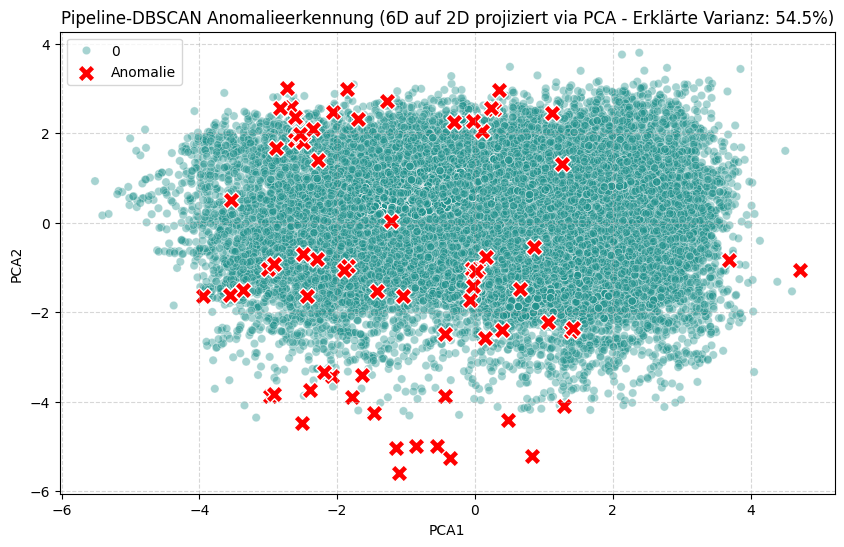

In [15]:
# ==================================================================
# 4. Visualisierung via PCA (auf den transformierten Daten)
# ==================================================================

basis_features = schiefe_features + normale_features

X_transformed = dbscan_pipeline.named_steps['preprocessor'].transform(df_X[basis_features])

# PCA initialisieren und auf 2 Hauptkomponenten festlegen
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

df_X['PCA1'] = X_pca[:, 0]
df_X['PCA2'] = X_pca[:, 1]

# Varianzberechnung direkt nach dem PCA-Fit durchführen
var_exp = pca.explained_variance_ratio_
total_var = np.sum(var_exp) * 100

# Plot erstellen
plt.figure(figsize=(10, 6))

# Normale Daten im Hintergrund zeichnen
sns.scatterplot(
    data=df_X[~df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    hue='Cluster', palette='viridis', alpha=0.4
)

# Anomalien markant in Rot hervorheben
sns.scatterplot(
    data=df_X[df_X['Is_Anomaly']], 
    x='PCA1', y='PCA2', 
    color='red', marker='X', s=150, label='Anomalie'
)

# Dynamischen Titel mit der erklärten Varianz setzen
plt.title(f'Pipeline-DBSCAN Anomalieerkennung (6D auf 2D projiziert via PCA - Erklärte Varianz: {total_var:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Diagramm final ausgeben
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3796\4060327774.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['tSNE1'] = X_tsne[:, 0]
C:\Users\User\AppData\Local\Temp\ipykernel_3796\4060327774.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X['tSNE2'] = X_tsne[:, 1]


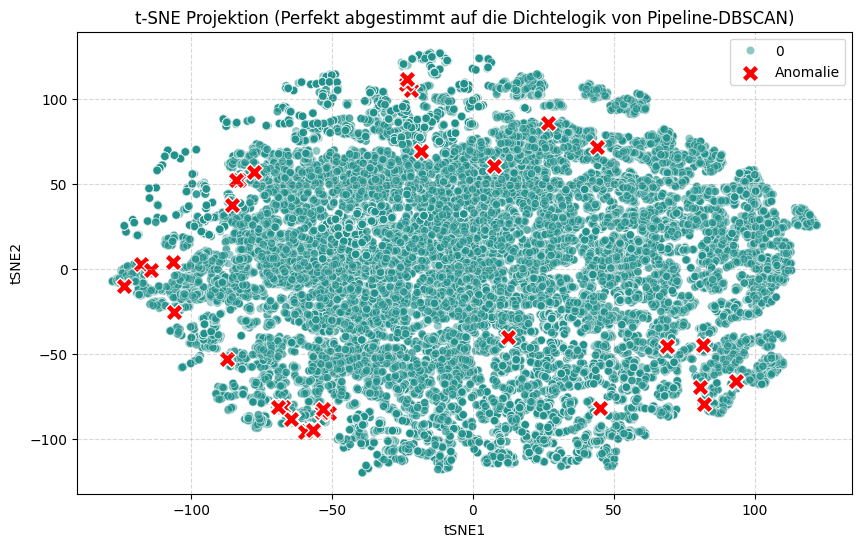

In [17]:
from sklearn.manifold import TSNE

# Sicherstellen, dass die Feature-Liste der Zelle bekannt ist
basis_features = ['air_speed', 'metabolic_rate', 'clothing_ensemble_insulation', 'air_temperature', 'relative_humidity', 'outdoor_air_temperature']

# 1. Die fertig transformierten Daten aus der bestehenden Pipeline holen
X_transformed = dbscan_pipeline.named_steps['preprocessor'].transform(df_X[basis_features])

# 2. t-SNE initialisieren und auf den transformierten Daten fitten
# Perplexity=30 ist ein super Standardwert für die Nachbarschaftsdichte
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_transformed)

# 3. t-SNE-Komponenten im DataFrame speichern
df_X['tSNE1'] = X_tsne[:, 0]
df_X['tSNE2'] = X_tsne[:, 1]

# 4. Diagramm zeichnen
plt.figure(figsize=(10, 6))

# Normale Daten im Hintergrund zeichnen
sns.scatterplot(
    data=df_X[~df_X['Is_Anomaly']], 
    x='tSNE1', y='tSNE2', 
    hue='Cluster', palette='viridis', alpha=0.5
)

# Anomalien markant in Rot hervorheben
sns.scatterplot(
    data=df_X[df_X['Is_Anomaly']], 
    x='tSNE1', y='tSNE2', 
    color='red', marker='X', s=150, label='Anomalie'
)

# Titel und Layout
plt.title('t-SNE Projektion (Perfekt abgestimmt auf die Dichtelogik von Pipeline-DBSCAN)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [19]:
# 6. Anomalien filtern und exportieren

if num_anomalies > 0:
    # Nur die Zeilen extrahieren, die als Anomalie (-1) klassifiziert wurden
    df_anomalies = df_X[df_X['Is_Anomaly'] == True].copy()
    
    features = schiefe_features + normale_features

    # Optional: Die künstlichen PCA- und Cluster-Spalten für den Export entfernen,
    # damit Sie nur die reinen physikalischen Sensorwerte in der Datei haben
    columns_to_export = [col for col in features] # Exportiert nur die 6 echten Sensoren
    # Falls Sie das berechnete Cluster-Label (-1) behalten wollen, nutzen Sie stattdessen:
    # columns_to_export = features + ['Cluster']
    
    # Speicherpfad definieren (wird im selben Ordner wie Ihr Skript abgelegt)
    output_filename = "erkannte_anomalien_dbscan.csv"
    
    # Als CSV speichern (ohne den Pandas-Index, um die Datei sauber zu halten)
    df_anomalies[columns_to_export].to_csv(output_filename, index=False, sep=';')
    
    print(f"--> ERFOLG: {num_anomalies} Anomalien wurden erfolgreich in '{output_filename}' exportiert.")
    
    # Die ersten Zeilen der Anomalien direkt im Terminal zur Kontrolle anzeigen
    print("\nAuszug der erkannten Fehlermessungen:")
    display(df_anomalies[features])
else:
    print("--> Info: Es wurden keine Anomalien gefunden. Es wurde keine Datei erstellt.")


--> ERFOLG: 74 Anomalien wurden erfolgreich in 'erkannte_anomalien_dbscan.csv' exportiert.

Auszug der erkannten Fehlermessungen:


,air_speed,metabolic_rate,clothing_ensemble_insulation,air_temperature,outdoor_air_temperature,relative_humidity
15859,0.00,0.9,2.25,31.3,29.96,59.2
15860,0.14,0.9,2.25,31.7,29.96,60.3
15861,0.61,0.9,2.25,31.3,29.96,64.0
15911,0.82,0.9,2.19,33.0,31.38,59.5
15912,0.42,0.9,2.19,34.2,31.38,63.7
...,...,...,...,...,...,...
107471,0.29,1.2,0.10,26.2,-21.75,74.4
107576,0.31,0.8,0.63,26.6,-2.70,66.0
107670,0.20,1.6,0.49,27.3,-23.35,73.8
107675,0.39,1.2,0.21,27.1,-23.35,74.8


In [ ]:
#df_regression_anomalie.csv
df_anomalie_regression = pd.read_csv('df_regression_anomalie.csv')
df_anomalie_regression

Index(['outdoor_air_temperature', 'air_temperature', 'relative_humidity',
       'season', 'building_type', 'air_speed', 'metabolic_rate',
       'climate_zone', 'cooling_type', 'Ziel', 'berechnet', 'delta_abs',
       'country'],
      dtype='object')

In [ ]:
df_anomalie_regression.columns

In [ ]:
df_anomalies.columns

Index(['outdoor_air_temperature', 'air_temperature', 'relative_humidity',
       'season', 'building_type', 'air_speed', 'metabolic_rate',
       'climate_zone', 'cooling_type', 'clothing_ensemble_insulation',
       'Cluster', 'Is_Anomaly', 'PCA1', 'PCA2', 'tSNE1', 'tSNE2'],
      dtype='object')

In [25]:
df_anomalies_filtered = df_anomalies[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'building_type', 'air_speed', 'metabolic_rate', 'climate_zone', 'cooling_type']]

In [27]:
df_schnittmenge = pd.merge(df_anomalie_regression, df_anomalies_filtered, how='inner')

print(f"Anzahl Zeilen in df1: {len(df_anomalie_regression)}")
print(f"Anzahl Zeilen in df2: {len(df_anomalies_filtered)}")
print(f"Größe der Schnittmenge: {len(df_schnittmenge)}")

Anzahl Zeilen in df1: 100
Anzahl Zeilen in df2: 74
Größe der Schnittmenge: 3


In [28]:
df_schnittmenge.to_csv('anomalien_schnittmenge.csv', index=False)